# **CV 1st Assignment**
Nama : [Finanazwa Ayesha] NIM : [24/532953/PA/22556]

*Implementation For Image Enhancement*

Saving sharp4.webp to sharp4.webp


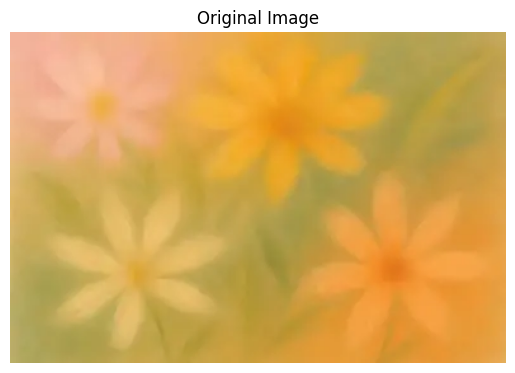

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()
filename = list(uploaded.keys())[0]

image = cv2.imread(filename)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# convolution
def convolution(image, kernel):
    k = kernel.shape[0] // 2
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    output = np.zeros_like(gray)

    for x in range(k, gray.shape[0]-k):
        for y in range(k, gray.shape[1]-k):
            region = gray[x-k:x+k+1, y-k:y+k+1]
            value = np.sum(region * kernel)
            output[x,y] = np.clip(value, 0, 255)
    return output

# show image

def show_image(title, img, cmap_type=None):
    plt.imshow(img, cmap=cmap_type)
    plt.title(title)
    plt.axis("off")
    plt.show()

def compare(img1, img2, title1="Image 1", title2="Image 2"):
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.imshow(img1, cmap="gray")
    plt.title(title1)
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(img2, cmap="gray")
    plt.title(title2)
    plt.axis("off")

    plt.show()

show_image("Original Image", image_rgb)

# Sharpening Filter

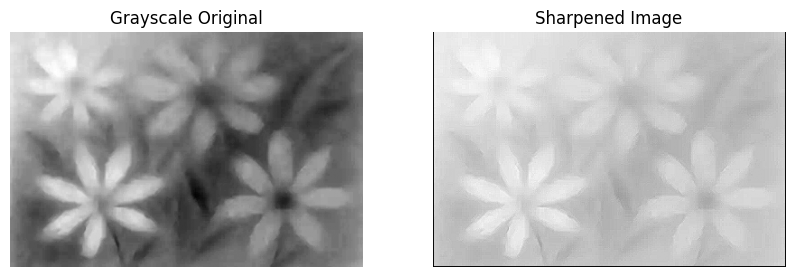

In [11]:
sharpen_kernel = np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]])
sharpened_image = convolution(image_rgb, sharpen_kernel)
sharpened_image = np.clip(sharpened_image, 0, 255).astype(np.uint8)

compare(cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY),
        sharpened_image,
        "Grayscale Original",
        "Sharpened Image")

# Median Filter (Noise Removal)

In [13]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]

image = cv2.imread(filename)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

Saving cvsnoopy2.jpg to cvsnoopy2.jpg


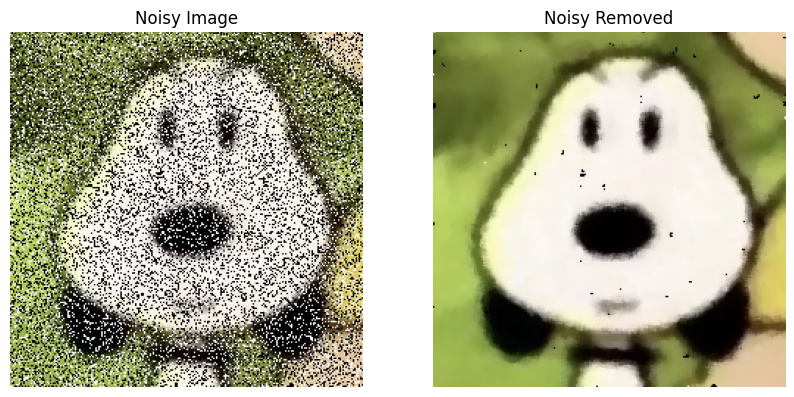

In [14]:
def add_salt_pepper_noise(image, amount=0.05):
    noisy = image.copy()
    h, w, c = image.shape

    num_noise = int(amount * h * w)

    for _ in range(num_noise // 2):
        x = np.random.randint(0, h)
        y = np.random.randint(0, w)
        noisy[x, y] = [255, 255, 255]

    for _ in range(num_noise // 2):
        x = np.random.randint(0, h)
        y = np.random.randint(0, w)
        noisy[x, y] = [0, 0, 0]

    return noisy

noisy_img = add_salt_pepper_noise(image_rgb, amount=0.5)

# remove
removal = cv2.medianBlur(noisy_img, 5)

# bandingin
compare(noisy_img, removal, "Noisy Image", "Noisy Removed")

# Darkening

Saving bright.jpg to bright.jpg


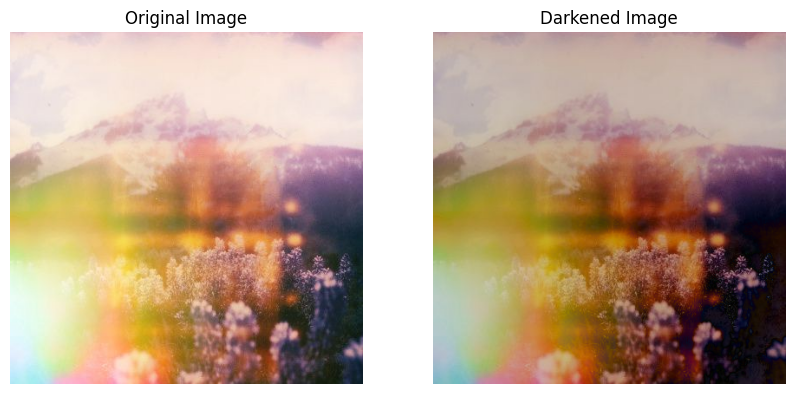

In [15]:
from google.colab import files
uploaded = files.upload()
filename = list(uploaded.keys())[0]

image_dark = cv2.imread(filename)
image_dark = cv2.cvtColor(image_dark, cv2.COLOR_BGR2RGB)

dark_img = cv2.convertScaleAbs(image_dark, alpha=1, beta=-50)

compare(image_dark, dark_img,
        "Original Image", "Darkened Image")

# Brightening

Saving dark1.jpg to dark1.jpg


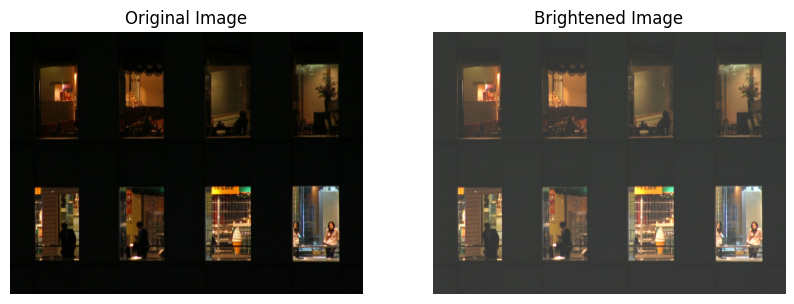

In [16]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]

image_bright = cv2.imread(filename)
image_bright = cv2.cvtColor(image_bright, cv2.COLOR_BGR2RGB)

bright_img = cv2.convertScaleAbs(image_bright, alpha=1, beta=50)

compare(image_bright, bright_img,
        "Original Image", "Brightened Image")

# Contrast Enhancement

In [17]:
# function to compare 3 image
def compare3(img1, img2, img3, title1="Image 1", title2="Image 2", title3="Image 3"):
    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(img1, cmap="gray" if len(img1.shape)==2 else None)
    plt.title(title1)
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(img2, cmap="gray" if len(img2.shape)==2 else None)
    plt.title(title2)
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(img3, cmap="gray" if len(img3.shape)==2 else None)
    plt.title(title3)
    plt.axis("off")

    plt.show()

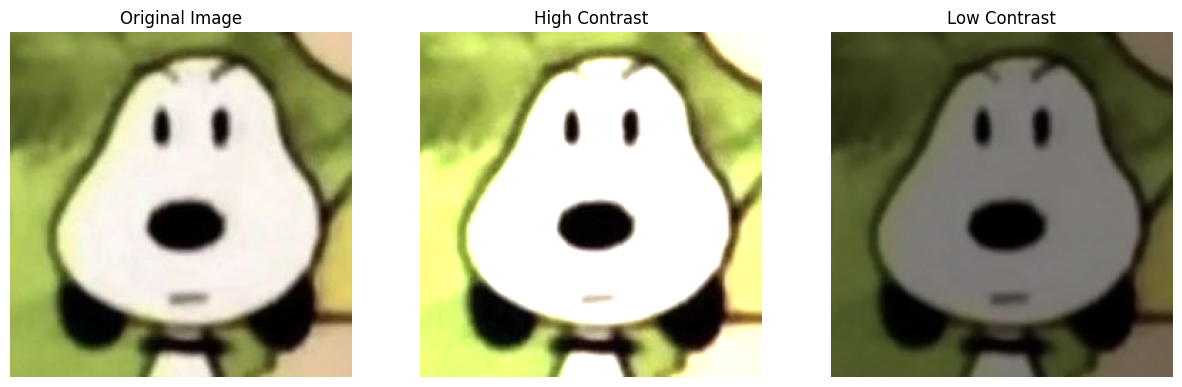

In [18]:
high_contrast_img = cv2.convertScaleAbs(image_rgb, alpha=1.5, beta=0)

low_contrast_img = cv2.convertScaleAbs(image_rgb, alpha=0.5, beta=0)

compare3(image_rgb, high_contrast_img, low_contrast_img,
         "Original Image", "High Contrast", "Low Contrast")